In [1]:
import math

def mean(data):
    return sum(data) / len(data)

def variance(data, mean_value):
    return sum((x - mean_value) ** 2 for x in data) / (len(data) - 1)

def t_test(group1, group2):
    mean1, mean2 = mean(group1), mean(group2)
    var1, var2 = variance(group1, mean1), variance(group2, mean2)
    n1, n2 = len(group1), len(group2)

    # Calculate the T-statistic
    t_stat = (mean1 - mean2) / math.sqrt((var1 / n1) + (var2 / n2))
    return t_stat

# Test Data
group1 = [1.85, 1.78, 1.82]
group2 = [1.73, 1.76, 1.74]
t_statistic = t_test(group1, group2)
print(f"T-statistic: {t_statistic:.4f}")


T-statistic: 3.3166


In [2]:
def wilcoxon_signed_rank_test(before, after):
    n = len(before)
    diffs = [after[i] - before[i] for i in range(n)]
    abs_diffs = [(i, abs(d)) for i, d in enumerate(diffs) if d != 0]  # Ignore zero diffs
    
    # Rank the absolute differences
    abs_diffs.sort(key=lambda x: x[1])  # Sort by absolute difference
    ranks = {i: rank + 1 for rank, (i, _) in enumerate(abs_diffs)}  # Assign ranks

    # Sum of positive and negative ranks
    pos_rank_sum = sum(ranks[i] for i, d in enumerate(diffs) if d > 0)
    neg_rank_sum = sum(ranks[i] for i, d in enumerate(diffs) if d < 0)

    # Test statistic W is the smaller of the two sums
    W = min(pos_rank_sum, neg_rank_sum)
    return W

# Test Data
before = [88, 92, 94, 89]
after = [90, 95, 91, 94]
W = wilcoxon_signed_rank_test(before, after)
print(f"Wilcoxon Signed-Rank Test Statistic: W = {W}")


Wilcoxon Signed-Rank Test Statistic: W = 3


In [3]:
def rank_data(data):
    # Rank data row-wise
    ranked_data = []
    for row in data:
        sorted_row = sorted((val, idx) for idx, val in enumerate(row))
        ranks = [0] * len(row)
        for rank, (val, idx) in enumerate(sorted_row):
            ranks[idx] = rank + 1
        ranked_data.append(ranks)
    return ranked_data

def friedman_test(data):
    n = len(data)    # Number of subjects
    k = len(data[0]) # Number of conditions

    # Rank the data
    ranked_data = rank_data(data)

    # Sum the ranks for each condition
    rank_sums = [sum(ranks[j] for ranks in ranked_data) for j in range(k)]

    # Compute the Friedman statistic
    chi_square = (12 / (n * k * (k + 1))) * sum(R_j ** 2 for R_j in rank_sums) - 3 * n * (k + 1)
    return chi_square

# Test Data (Each row is a subject, each column a condition)
data = [
    [10, 9, 8],  # Subject 1
    [8, 7, 6],   # Subject 2
    [7, 5, 4],   # Subject 3
]
chi_square_stat = friedman_test(data)
print(f"Friedman Test Statistic: Chi^2 = {chi_square_stat:.4f}")


Friedman Test Statistic: Chi^2 = 6.0000


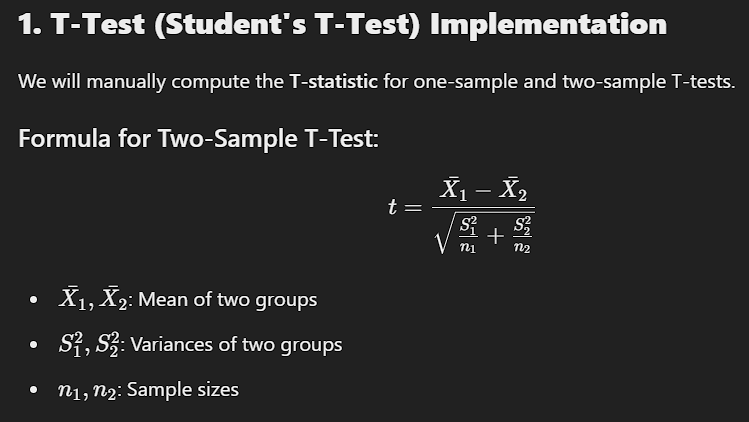

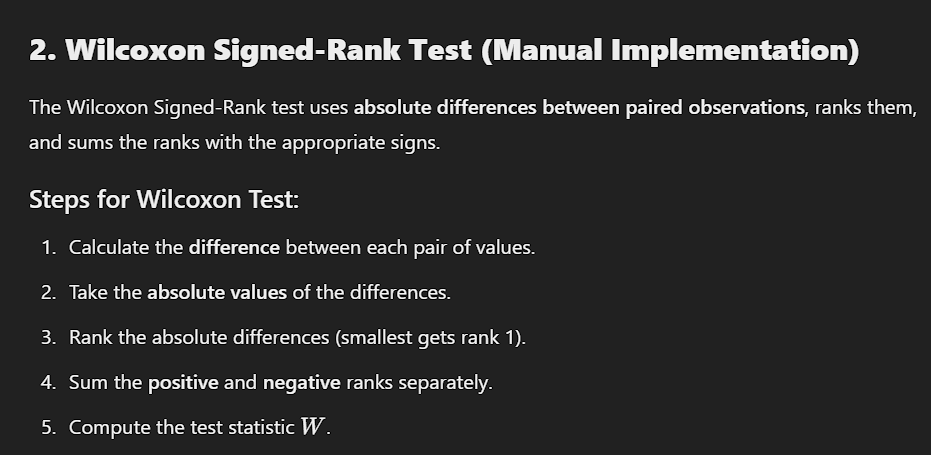

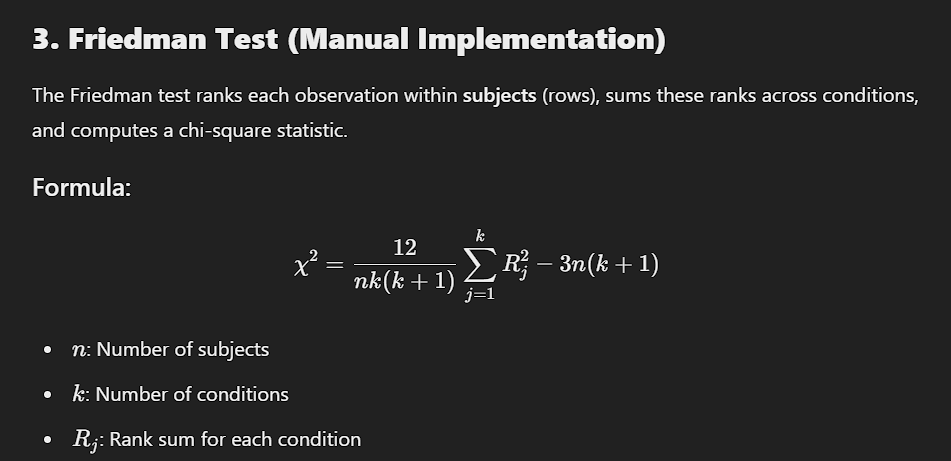